In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from datetime import datetime, date


df = pd.read_csv("../data/kc_house_data.csv")


In [64]:
print(df.shape)
print(df.info())
print(df.describe())

(21613, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64

In [65]:
df = df.dropna(subset=['id']) 
df["date"] = pd.to_datetime(df["date"])
print(df.dtypes)


id                        int64
date             datetime64[ns]
price                   float64
bedrooms                  int64
bathrooms               float64
sqft_living               int64
sqft_lot                  int64
floors                  float64
waterfront                int64
view                      int64
condition                 int64
grade                     int64
sqft_above                int64
sqft_basement             int64
yr_built                  int64
yr_renovated              int64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15             int64
sqft_lot15                int64
dtype: object


In [66]:
#IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
df = df[(df["price"] >= Q1 - 1.5*IQR) & (df["price"] <= Q3 + 1.5*IQR)]

In [67]:
print(df.shape)

(20467, 21)


In [68]:
#features
df["house_age"] = 2025 - df["yr_built"]
df['price_per_sqft'] = df['price'] / df['sqft_living']
df["was_renovated"] = np.where(df["yr_renovated"] > 0, 1, 0)
df['total_rooms'] = df['bedrooms'] + df['bathrooms']



In [69]:
df = df.drop(columns=["id", "date" , "yr_renovated", "zipcode"])

In [70]:
print(df.shape)

(20467, 21)


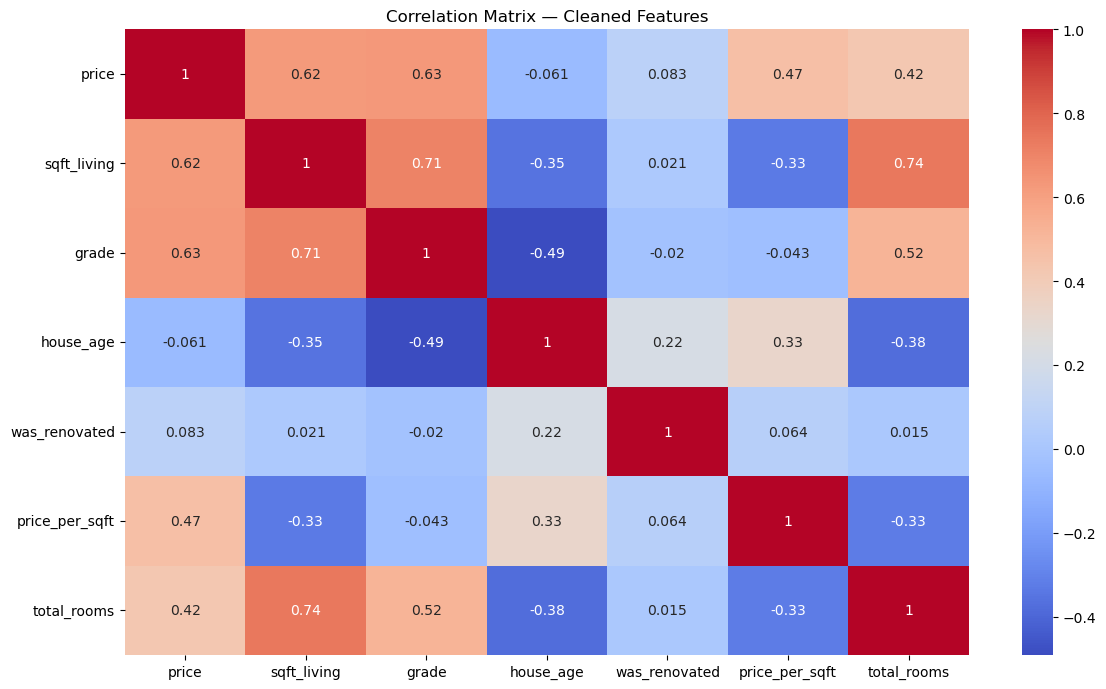

In [71]:
##Correlation heatmap of all new features — which features correlate most with price?
plt.figure(figsize=(12, 7))
correlation = df[['price', 'sqft_living', 'grade', 'house_age',
                   'was_renovated', 'price_per_sqft', 'total_rooms']].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix — Cleaned Features")
plt.tight_layout()
plt.savefig("correlation_cleaned_matrix.png")
plt.show()

#sqft_living and price have a +0.7 correlation and grade has a +0.67 correlation with price. two are the highest so far

In [72]:
df.to_csv("../data/cleaned_house_data.csv", index=False)
print(f"Cleaned dataset saved — shape: {df.shape}")

Cleaned dataset saved — shape: (20467, 21)
